## GARCH

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, kpss
from scipy import stats
from arch import arch_model
from arch.__future__ import reindexing
import warnings
warnings.filterwarnings('ignore')
from sklearn.metrics import mean_squared_error, mean_absolute_error

%matplotlib inline

In [2]:
# Parameters
TICKER = '^NSEI'  # Yahoo ticker for NIFTY 50
START = '2014-01-01'
END = '2016-12-31'
OUT_DIR = os.path.join('..', 'data')
os.makedirs(OUT_DIR, exist_ok=True)
print('Output dir:', OUT_DIR)

Output dir: ..\data


In [3]:
df = yf.download(TICKER, start=START, end=END, progress=False)
if df.empty:
    raise RuntimeError('Data download returned empty DataFrame. Confirm ticker and network access.')
csv_path = os.path.join(OUT_DIR, 'nifty_2014_2016.csv')
df.to_csv(csv_path)
print('Saved:', csv_path)
df.head()

Saved: ..\data\nifty_2014_2016.csv


Price,Close,High,Low,Open,Volume
Ticker,^NSEI,^NSEI,^NSEI,^NSEI,^NSEI
Date,,,,,
2014-01-02,6221.149902,6358.299805,6211.299805,6301.250000,158100
2014-01-03,6211.149902,6221.700195,6171.250000,6194.549805,139000
2014-01-06,6191.450195,6224.700195,6170.250000,6220.850098,118300
2014-01-07,6162.250000,6221.500000,6144.750000,6203.899902,138600
2014-01-08,6174.600098,6192.100098,6160.350098,6178.049805,146900


Returns Statistics:
count    727.000000
mean       0.000378
std        0.009382
min       -0.060973
25%       -0.004309
50%        0.000426
75%        0.005707
max        0.033115
Name: Returns, dtype: float64

Skewness: -0.5231
Kurtosis: 2.8481


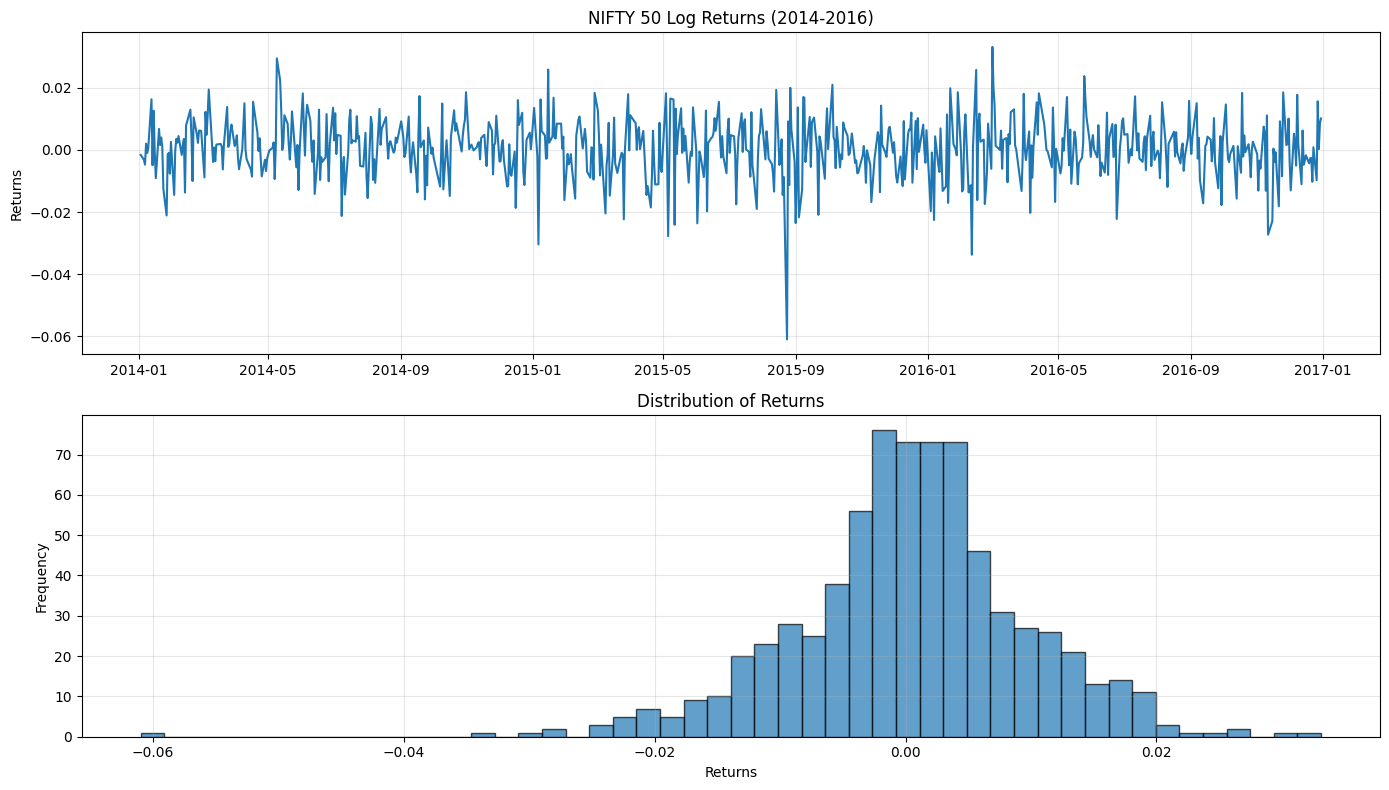

In [4]:
df['Returns'] = np.log(df['Close'] / df['Close'].shift(1))
df = df.dropna()

print('Returns Statistics:')
print(df['Returns'].describe())
print(f'\nSkewness: {df["Returns"].skew():.4f}')
print(f'Kurtosis: {df["Returns"].kurtosis():.4f}')

fig, axes = plt.subplots(2, 1, figsize=(14, 8))
axes[0].plot(df.index, df['Returns'])
axes[0].set_title('NIFTY 50 Log Returns (2014-2016)')
axes[0].set_ylabel('Returns')
axes[0].grid(True, alpha=0.3)

axes[1].hist(df['Returns'], bins=50, edgecolor='black', alpha=0.7)
axes[1].set_title('Distribution of Returns')
axes[1].set_xlabel('Returns')
axes[1].set_ylabel('Frequency')
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [5]:
train_size = int(len(df) * 0.8)
train_data = df.iloc[:train_size]
test_data = df.iloc[train_size:]

print(f'Training data: {len(train_data)} observations ({train_data.index[0]} to {train_data.index[-1]})')
print(f'Testing data: {len(test_data)} observations ({test_data.index[0]} to {test_data.index[-1]})')

train_returns = train_data['Returns'] * 100
test_returns = test_data['Returns'] * 100

Training data: 581 observations (2014-01-03 00:00:00 to 2016-05-27 00:00:00)
Testing data: 146 observations (2016-05-30 00:00:00 to 2016-12-30 00:00:00)


In [6]:
# Grid search for GARCH(p, q) parameters
p_values = [1, 2, 3]
q_values = [1, 2, 3]

results = []

print('Running GARCH Grid Search...\n')
for p in p_values:
    for q in q_values:
        try:
            # Fit GARCH(p, q) model
            model = arch_model(train_returns, vol='Garch', p=p, q=q, rescale=False)
            model_fit = model.fit(disp='off', show_warning=False)
            
            # Store results
            results.append({
                'p': p,
                'q': q,
                'AIC': model_fit.aic,
                'BIC': model_fit.bic,
                'Log-Likelihood': model_fit.loglikelihood
            })
            
            print(f'GARCH({p},{q}) - AIC: {model_fit.aic:.2f}, BIC: {model_fit.bic:.2f}')
            
        except Exception as e:
            print(f'GARCH({p},{q}) - Failed: {str(e)}')
            
# Convert results to DataFrame
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('AIC')

print('\n' + '='*60)
print('Grid Search Results (sorted by AIC):')
print('='*60)
print(results_df.to_string(index=False))

# Best model
best_p = results_df.iloc[0]['p']
best_q = results_df.iloc[0]['q']
print(f'\nBest Model: GARCH({int(best_p)},{int(best_q)})')

# Save grid search results
grid_results_path = os.path.join(OUT_DIR, 'garch_grid_search_results.csv')
results_df.to_csv(grid_results_path, index=False)
print(f'Saved grid search results to: {grid_results_path}')

Running GARCH Grid Search...

GARCH(1,1) - AIC: 1606.51, BIC: 1623.96
GARCH(1,2) - AIC: 1608.51, BIC: 1630.33
GARCH(1,3) - AIC: 1605.45, BIC: 1631.64
GARCH(2,1) - AIC: 1602.56, BIC: 1624.39
GARCH(2,2) - AIC: 1600.94, BIC: 1627.13
GARCH(2,3) - AIC: 1602.64, BIC: 1633.20
GARCH(3,1) - AIC: 1604.56, BIC: 1630.75
GARCH(3,2) - AIC: 1602.94, BIC: 1633.50
GARCH(3,3) - AIC: 1604.64, BIC: 1639.56

Grid Search Results (sorted by AIC):
 p  q         AIC         BIC  Log-Likelihood
 2  2 1600.943830 1627.132334     -794.471915
 2  1 1602.562900 1624.386653     -796.281450
 2  3 1602.641942 1633.195198     -794.320971
 3  2 1602.943829 1633.497085     -794.471915
 3  1 1604.562900 1630.751404     -796.281450
 3  3 1604.641942 1639.559948     -794.320971
 1  3 1605.452002 1631.640506     -796.726001
 1  1 1606.505507 1623.964510     -799.252754
 1  2 1608.505507 1630.329261     -799.252754

Best Model: GARCH(2,2)
Saved grid search results to: ..\data\garch_grid_search_results.csv
GARCH(2,2) - AIC: 16

In [7]:
best_model = arch_model(train_returns, vol='Garch', p=int(best_p), q=int(best_q), rescale=False)
best_model_fit = best_model.fit(disp='off')

print(best_model_fit.summary())

                     Constant Mean - GARCH Model Results                      
Dep. Variable:                Returns   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -794.472
Distribution:                  Normal   AIC:                           1600.94
Method:            Maximum Likelihood   BIC:                           1627.13
                                        No. Observations:                  581
Date:                Sun, Nov 16 2025   Df Residuals:                      580
Time:                        22:24:18   Df Model:                            1
                                 Mean Model                                
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
mu             0.0625  3.772e-02      1.658  9.741e-02 [-1.14

In [8]:
# Generate one-step-ahead forecasts using rolling window
predicted_volatility = []

for i in range(len(test_returns)):
    current_data = pd.concat([train_returns, test_returns.iloc[:i+1]])
    
    model = arch_model(current_data, vol='Garch', p=int(best_p), q=int(best_q), rescale=False)
    model_fit = model.fit(disp='off', show_warning=False)
    
    forecast = model_fit.forecast(horizon=1, reindex=False)
    pred_var = forecast.variance.values[-1, 0]
    predicted_volatility.append(np.sqrt(pred_var))
    
    if (i + 1) % 30 == 0:
        print(f'Progress: {i+1}/{len(test_returns)} forecasts completed')

predicted_volatility = np.array(predicted_volatility)

print(f'\nGenerated {len(predicted_volatility)} one-step-ahead forecasts')
print(f'Predicted volatility range: {predicted_volatility.min():.4f} to {predicted_volatility.max():.4f}')

Progress: 30/146 forecasts completed
Progress: 60/146 forecasts completed
Progress: 60/146 forecasts completed
Progress: 90/146 forecasts completed
Progress: 90/146 forecasts completed
Progress: 120/146 forecasts completed
Progress: 120/146 forecasts completed

Generated 146 one-step-ahead forecasts
Predicted volatility range: 0.7703 to 1.3849

Generated 146 one-step-ahead forecasts
Predicted volatility range: 0.7703 to 1.3849


In [9]:
# Calculate realized volatility using rolling window
window = 20  
realized_volatility = test_returns.rolling(window=window).std()

comparison_df = pd.DataFrame({
    'Date': test_data.index,
    'Returns': test_returns.values,
    'Predicted_Volatility': predicted_volatility,
    'Realized_Volatility': realized_volatility.values
})

comparison_df = comparison_df.dropna()
print('Volatility Comparison Data:')
print(comparison_df.head(10))

Volatility Comparison Data:
         Date   Returns  Predicted_Volatility  Realized_Volatility
19 2016-06-24 -2.223327              0.861925             0.763605
20 2016-06-27  0.075388              1.186536             0.760710
21 2016-06-28  0.408690              0.881818             0.766276
22 2016-06-29  0.932539              1.012317             0.793743
23 2016-06-30  1.015668              0.920225             0.819032
24 2016-07-01  0.488679              0.982062             0.825069
25 2016-07-04  0.507223              0.889942             0.827434
26 2016-07-05 -0.416003              0.909865             0.818375
27 2016-07-07  0.023392              0.865778             0.818334
28 2016-07-08 -0.176461              0.850286             0.793724


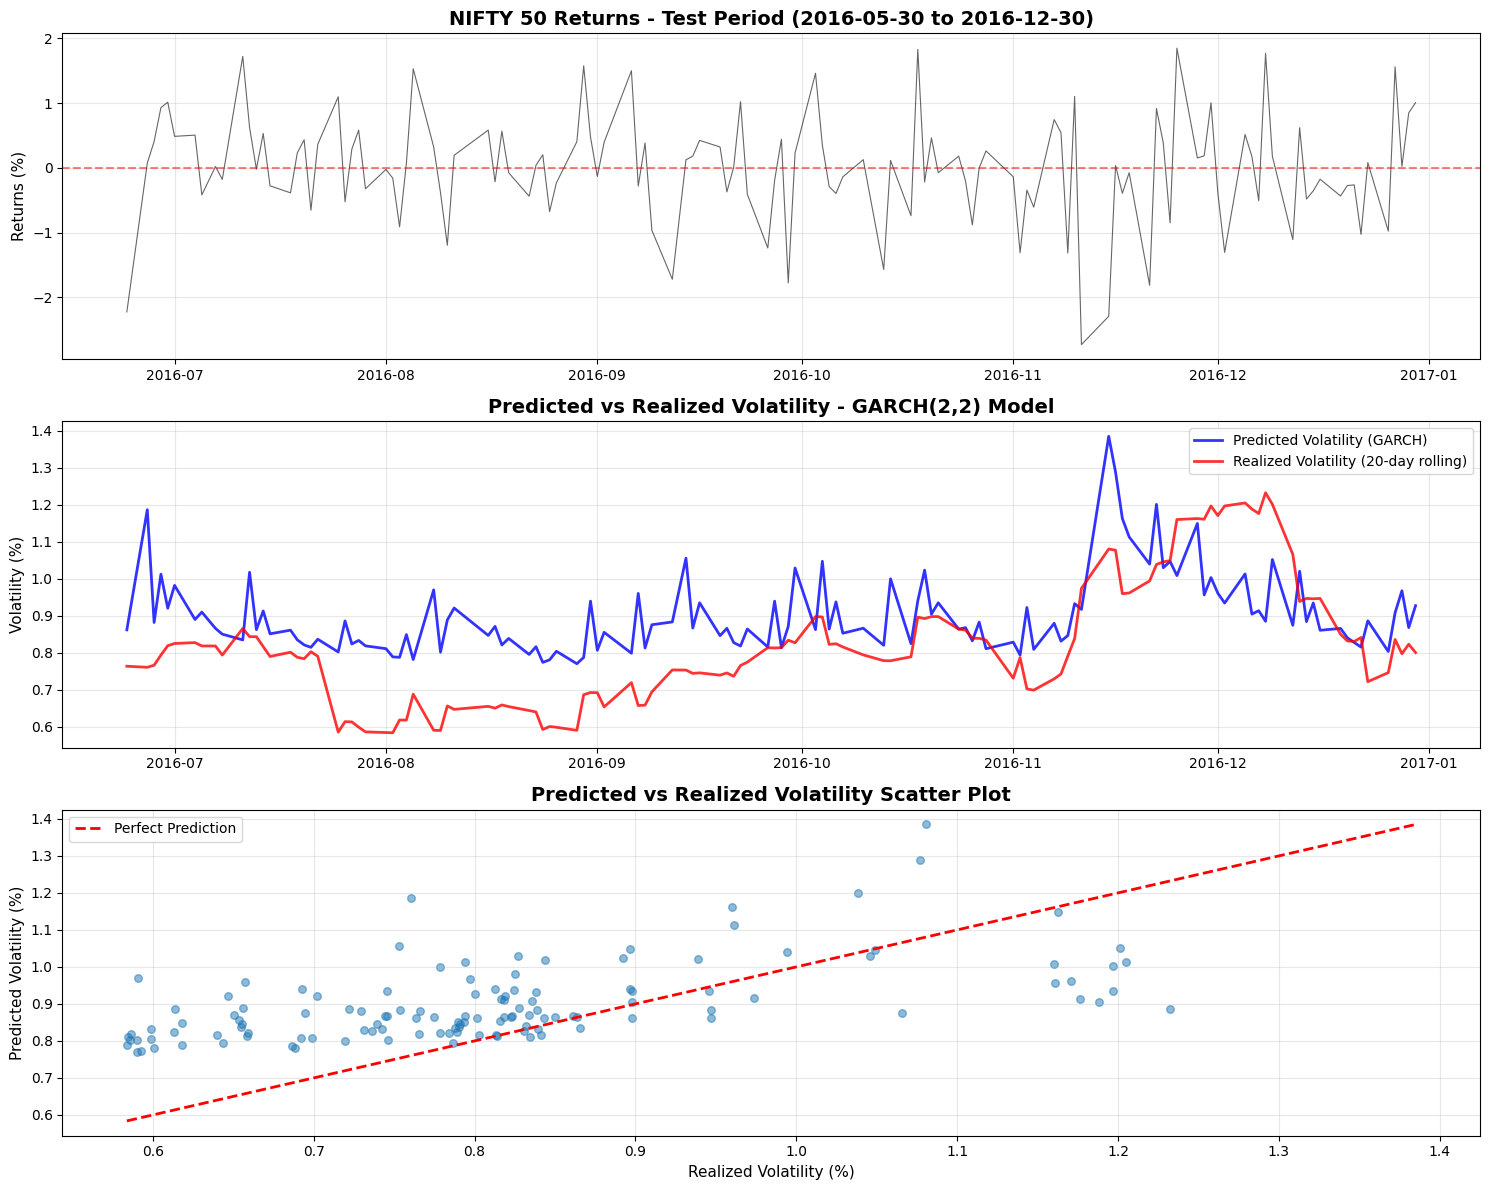


Saved volatility comparison plot to: ..\data\volatility_comparison.pdf
Correlation between Predicted and Realized Volatility: 0.5682


In [10]:
fig, axes = plt.subplots(3, 1, figsize=(15, 12))

axes[0].plot(comparison_df['Date'], comparison_df['Returns'], color='black', alpha=0.6, linewidth=0.8)
axes[0].set_title(f'NIFTY 50 Returns - Test Period ({test_data.index[0].strftime("%Y-%m-%d")} to {test_data.index[-1].strftime("%Y-%m-%d")})', 
                  fontsize=14, fontweight='bold')
axes[0].set_ylabel('Returns (%)', fontsize=11)
axes[0].grid(True, alpha=0.3)
axes[0].axhline(y=0, color='red', linestyle='--', alpha=0.5)

axes[1].plot(comparison_df['Date'], comparison_df['Predicted_Volatility'], 
             label='Predicted Volatility (GARCH)', color='blue', linewidth=2, alpha=0.8)
axes[1].plot(comparison_df['Date'], comparison_df['Realized_Volatility'], 
             label=f'Realized Volatility ({window}-day rolling)', color='red', linewidth=2, alpha=0.8)
axes[1].set_title(f'Predicted vs Realized Volatility - GARCH({int(best_p)},{int(best_q)}) Model', 
                  fontsize=14, fontweight='bold')
axes[1].set_ylabel('Volatility (%)', fontsize=11)
axes[1].legend(loc='upper right', fontsize=10)
axes[1].grid(True, alpha=0.3)

valid_idx = ~comparison_df['Realized_Volatility'].isna()
axes[2].scatter(comparison_df.loc[valid_idx, 'Realized_Volatility'], 
                comparison_df.loc[valid_idx, 'Predicted_Volatility'], 
                alpha=0.5, s=30)

min_vol = min(comparison_df.loc[valid_idx, 'Realized_Volatility'].min(), 
              comparison_df.loc[valid_idx, 'Predicted_Volatility'].min())
max_vol = max(comparison_df.loc[valid_idx, 'Realized_Volatility'].max(), 
              comparison_df.loc[valid_idx, 'Predicted_Volatility'].max())
axes[2].plot([min_vol, max_vol], [min_vol, max_vol], 'r--', linewidth=2, label='Perfect Prediction')

axes[2].set_xlabel('Realized Volatility (%)', fontsize=11)
axes[2].set_ylabel('Predicted Volatility (%)', fontsize=11)
axes[2].set_title('Predicted vs Realized Volatility Scatter Plot', fontsize=14, fontweight='bold')
axes[2].legend(loc='upper left', fontsize=10)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

fig_volatility = plt.figure(figsize=(15, 5))
ax = fig_volatility.add_subplot(111)
ax.plot(comparison_df['Date'], comparison_df['Predicted_Volatility'], 
        label='Predicted Volatility (GARCH)', color='blue', linewidth=2, alpha=0.8)
ax.plot(comparison_df['Date'], comparison_df['Realized_Volatility'], 
        label=f'Realized Volatility ({window}-day rolling)', color='red', linewidth=2, alpha=0.8)
ax.set_title(f'Predicted vs Realized Volatility - GARCH({int(best_p)},{int(best_q)}) Model', 
             fontsize=14, fontweight='bold')
ax.set_ylabel('Volatility (%)', fontsize=11)
ax.set_xlabel('Date', fontsize=11)
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()

pdf_path = os.path.join(OUT_DIR, 'volatility_comparison.pdf')
fig_volatility.savefig(pdf_path, format='pdf', bbox_inches='tight', dpi=300)
plt.close(fig_volatility)
print(f'\nSaved volatility comparison plot to: {pdf_path}')

corr = comparison_df[['Predicted_Volatility', 'Realized_Volatility']].corr().iloc[0, 1]
print(f'Correlation between Predicted and Realized Volatility: {corr:.4f}')

In [11]:

valid_data = comparison_df.dropna()

mse = mean_squared_error(valid_data['Realized_Volatility'], valid_data['Predicted_Volatility'])
rmse = np.sqrt(mse)
mae = mean_absolute_error(valid_data['Realized_Volatility'], valid_data['Predicted_Volatility'])

print('Forecast Accuracy Metrics:')
print('='*50)
print(f'Mean Squared Error (MSE):       {mse:.6f}')
print(f'Root Mean Squared Error (RMSE): {rmse:.6f}')
print(f'Mean Absolute Error (MAE):      {mae:.6f}')
print(f'Correlation:                    {corr:.6f}')
print('='*50)

Forecast Accuracy Metrics:
Mean Squared Error (MSE):       0.024928
Root Mean Squared Error (RMSE): 0.157886
Mean Absolute Error (MAE):      0.128753
Correlation:                    0.568197


## ARMA + GARCH

In [12]:
arima_garch_model = arch_model(train_returns, mean='ARX', lags=1, vol='Garch', p=2, q=2, rescale=False)
arima_garch_fit = arima_garch_model.fit(disp='off')

print('ARMA(1,1) + GARCH(2,2) Model Summary:')
print('='*78)
print(arima_garch_fit.summary())

ARMA(1,1) + GARCH(2,2) Model Summary:
                           AR - GARCH Model Results                           
Dep. Variable:                Returns   R-squared:                       0.012
Mean Model:                        AR   Adj. R-squared:                  0.010
Vol Model:                      GARCH   Log-Likelihood:               -788.634
Distribution:                  Normal   AIC:                           1591.27
Method:            Maximum Likelihood   BIC:                           1621.81
                                        No. Observations:                  580
Date:                Sun, Nov 16 2025   Df Residuals:                      578
Time:                        22:24:25   Df Model:                            2
                                 Mean Model                                
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
Const          0.0582  

In [13]:
predicted_returns_arima_garch = []
predicted_variance = []

print('Generating rolling forecasts with ARMA(1,1) + GARCH(2,2)...\n')

for i in range(len(test_returns)):
    current_data = pd.concat([train_returns, test_returns.iloc[:i+1]])
    
    model = arch_model(current_data, mean='ARX', lags=1, vol='Garch', p=2, q=2, rescale=False)
    model_fit = model.fit(disp='off', show_warning=False)
    
    forecast = model_fit.forecast(horizon=1, reindex=False)
    pred_return = forecast.mean.values[-1, 0]
    pred_var = forecast.variance.values[-1, 0]
    
    predicted_returns_arima_garch.append(pred_return)
    predicted_variance.append(pred_var)
    
    if (i + 1) % 30 == 0:
        print(f'Progress: {i+1}/{len(test_returns)} forecasts completed')

predicted_returns_arima_garch = np.array(predicted_returns_arima_garch)
predicted_variance = np.array(predicted_variance)
predicted_volatility = np.sqrt(predicted_variance)

print(f'Predicted returns range: {predicted_returns_arima_garch.min():.4f} to {predicted_returns_arima_garch.max():.4f}')
print(f'Predicted volatility range: {predicted_volatility.min():.4f} to {predicted_volatility.max():.4f}')

Generating rolling forecasts with ARMA(1,1) + GARCH(2,2)...



Progress: 30/146 forecasts completed
Progress: 60/146 forecasts completed
Progress: 60/146 forecasts completed
Progress: 90/146 forecasts completed
Progress: 90/146 forecasts completed
Progress: 120/146 forecasts completed
Progress: 120/146 forecasts completed
Predicted returns range: -0.2373 to 0.2722
Predicted volatility range: 0.7509 to 1.4517
Predicted returns range: -0.2373 to 0.2722
Predicted volatility range: 0.7509 to 1.4517


In [14]:
initial_price = train_data['Close'].iloc[-1]
actual_prices = test_data['Close'].values.ravel()

predicted_prices = np.zeros(len(predicted_returns_arima_garch))
predicted_prices[0] = initial_price * (1 + predicted_returns_arima_garch[0] / 100)

for i in range(1, len(predicted_returns_arima_garch)):
    predicted_prices[i] = actual_prices[i-1] * (1 + predicted_returns_arima_garch[i] / 100)

z_score = 1.96

lower_band = predicted_prices - z_score * (predicted_volatility / 100) * predicted_prices
upper_band = predicted_prices + z_score * (predicted_volatility / 100) * predicted_prices

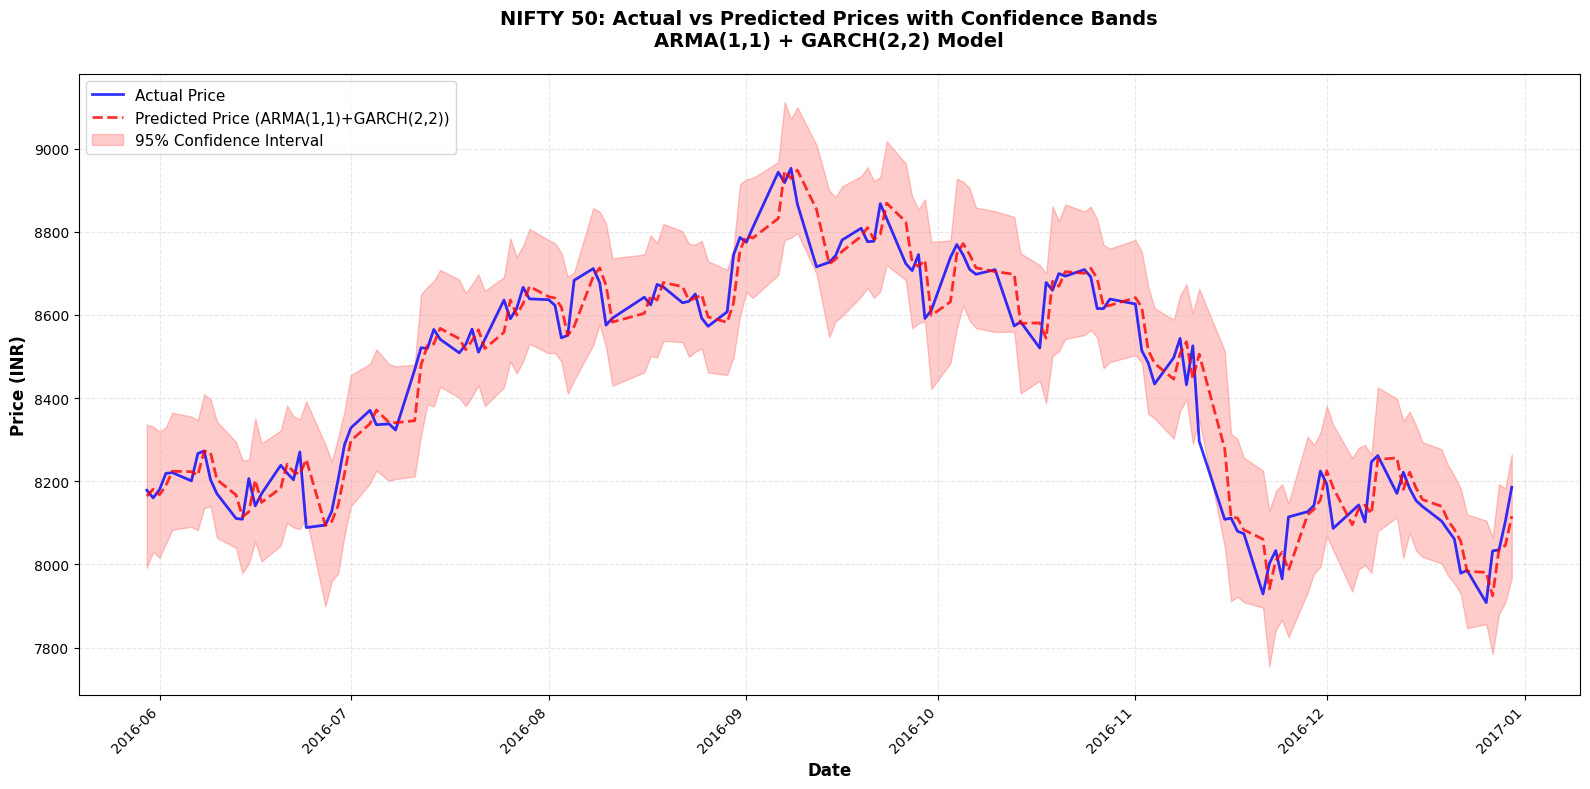


ARMA(1,1) + GARCH(2,2) Price Forecast Performance
Mean Absolute Error (MAE):        44.58
Root Mean Squared Error (RMSE):   60.14
Mean Absolute Percentage Error:   0.53%
Points within 95% CI:              144/146 (98.6%)


In [15]:
fig, ax = plt.subplots(figsize=(16, 8))

ax.plot(test_data.index, actual_prices, 
        label='Actual Price', color='blue', linewidth=2, alpha=0.8)

ax.plot(test_data.index, predicted_prices, 
        label='Predicted Price (ARMA(1,1)+GARCH(2,2))', 
        color='red', linewidth=2, alpha=0.8, linestyle='--')

ax.fill_between(test_data.index, lower_band, upper_band, 
                alpha=0.2, color='red', label='95% Confidence Interval')

ax.set_xlabel('Date', fontsize=12, fontweight='bold')
ax.set_ylabel('Price (INR)', fontsize=12, fontweight='bold')
ax.set_title('NIFTY 50: Actual vs Predicted Prices with Confidence Bands\nARMA(1,1) + GARCH(2,2) Model', 
             fontsize=14, fontweight='bold', pad=20)
ax.legend(fontsize=11, loc='upper left')
ax.grid(True, alpha=0.3, linestyle='--')

plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.savefig("arma_garch.pdf")
plt.show()

mae_prices = mean_absolute_error(actual_prices, predicted_prices)
rmse_prices = np.sqrt(mean_squared_error(actual_prices, predicted_prices))
mape = np.mean(np.abs((actual_prices - predicted_prices) / actual_prices)) * 100

within_bands = np.sum((actual_prices >= lower_band) & (actual_prices <= upper_band))
total_points = len(actual_prices)
percentage_within = (within_bands / total_points) * 100

print('\n' + '='*60)
print('ARMA(1,1) + GARCH(2,2) Price Forecast Performance')
print('='*60)
print(f'Mean Absolute Error (MAE):        {mae_prices:.2f}')
print(f'Root Mean Squared Error (RMSE):   {rmse_prices:.2f}')
print(f'Mean Absolute Percentage Error:   {mape:.2f}%')
print(f'Points within 95% CI:              {within_bands}/{total_points} ({percentage_within:.1f}%)')
print('='*60)